In [7]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from scipy.ndimage import maximum_filter, gaussian_filter

In [9]:
from collections import deque

In [10]:
import matplotlib.colors as mcolors

In [11]:
from sklearn.metrics import pairwise_distances

In [12]:
salinas_data = scipy.io.loadmat('/content/Salinas_corrected.mat')
gt_data = scipy.io.loadmat('/content/Salinas_gt.mat')
print(salinas_data.keys())
print(gt_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'salinas_corrected'])
dict_keys(['__header__', '__version__', '__globals__', 'salinas_gt'])


In [13]:
X = salinas_data['salinas_corrected']
y = gt_data['salinas_gt']

print("Image shape:", X.shape)
print("Ground truth shape:", y.shape)

Image shape: (512, 217, 204)
Ground truth shape: (512, 217)


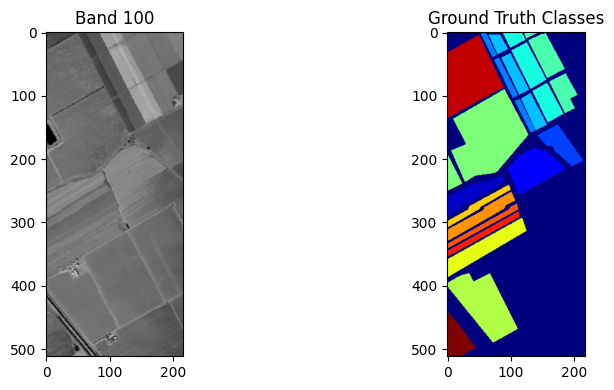

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.imshow(X[:, :, 100], cmap='gray')
plt.title("Band 100")

plt.subplot(1, 2, 2)
plt.imshow(y, cmap='jet')
plt.title("Ground Truth Classes")

plt.tight_layout()
plt.show()

In [15]:
def remove_noisy_bands(data, bad_band_indices):
    all_bands = np.arange(data.shape[2])
    good_band_indices = np.setdiff1d(all_bands, bad_band_indices)
    return data[:, :, good_band_indices]

def normalize_minmax(data):
    H, W, B = data.shape
    norm_data = np.zeros_like(data, dtype=np.float32)
    for b in range(B):
        band = data[:, :, b]
        min_val = band.min()
        max_val = band.max()
        if max_val - min_val != 0:
            norm_data[:, :, b] = (band - min_val) / (max_val - min_val)
        else:
            norm_data[:, :, b] = 0.0
    return norm_data

def normalize_zscore(data):
    H, W, B = data.shape
    norm_data = np.zeros_like(data, dtype=np.float32)
    for b in range(B):
        band = data[:, :, b]
        mean_val = np.mean(band)
        std_val = np.std(band)
        if std_val != 0:
            norm_data[:, :, b] = (band - mean_val) / std_val
        else:
            norm_data[:, :, b] = 0.0
    return norm_data


The data was cleaned by removing noisy bands identified from the source website, and then normalized using both Z-score normalization and Min-Max normalization.

In [16]:
bad_band_indices = list(range(108, 113)) + list(range(154, 168)) + [223]
cleaned_data = remove_noisy_bands(X, bad_band_indices)

minmax_data = normalize_minmax(cleaned_data)

zscore_data = normalize_zscore(cleaned_data)

In [17]:
def estimate_snr_per_band(data):
    H, W, B = data.shape
    snr_values = np.zeros(B)
    for b in range(B):
        band = data[:, :, b].flatten()
        mean_val = np.mean(band)
        var_val = np.var(band)
        snr = (mean_val ** 2) / var_val if var_val > 0 else 0
        snr_values[b] = snr
    return snr_values


The following code performs the same normalization as before however, this time the band selection is done using the Signal-to-Noise Ratio (SNR) method. Higher value implies better signal and less noise.

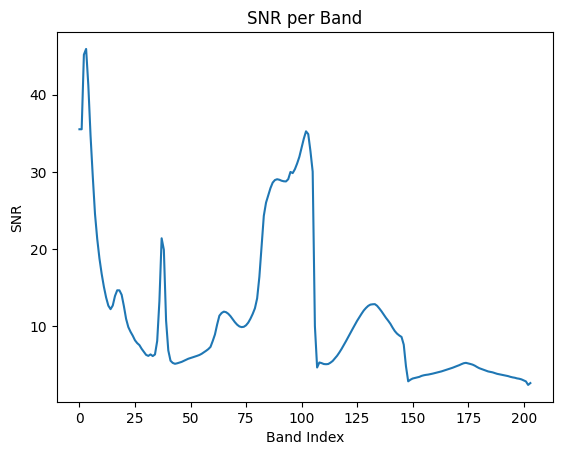

In [18]:
snr = estimate_snr_per_band(X)

import matplotlib.pyplot as plt
plt.plot(snr)
plt.xlabel("Band Index")
plt.ylabel("SNR")
plt.title("SNR per Band")
plt.show()

threshold = 20
good_band_indices = np.where(snr > threshold)[0]
cleaned_data_snr = X[:, :, good_band_indices]


minmax_data_snr = normalize_minmax(cleaned_data_snr)

zscore_data_snr = normalize_zscore(cleaned_data_snr)

In [19]:
def pca_reduce(data, n_components=3):
    H, W, B = data.shape
    reshaped = data.reshape(-1, B)
    mean_vec = np.mean(reshaped, axis=0)
    centered = reshaped - mean_vec
    cov = np.cov(centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx[:n_components]]
    reduced = centered @ eigvecs
    return reduced.reshape(H, W, n_components)

Automatic seed selection algorithms include K-Means, the Local Maxima method, and the Spectral Entropy method.

In [20]:
def kmeans_seeds(data, n_clusters=10, max_iter=100):
    H, W, C = data.shape
    X = data.reshape(-1, C)
    np.random.seed(0)
    centers = X[np.random.choice(X.shape[0], n_clusters, replace=False)]

    for _ in range(max_iter):
        dists = np.linalg.norm(X[:, None] - centers[None], axis=2)
        labels = np.argmin(dists, axis=1)
        new_centers = np.array([X[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
                                for i in range(n_clusters)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    seeds = []
    for c in centers:
        idx = np.argmin(np.linalg.norm(X - c, axis=1))
        y, x = divmod(idx, W)
        seeds.append((y, x))
    return seeds

def local_maxima_seeds(data, threshold=0.8, sigma=1.5,size = 50):
    spectral_norm = np.linalg.norm(data, axis=2)
    smoothed = gaussian_filter(spectral_norm, sigma=sigma)
    neighborhood = maximum_filter(smoothed, size)
    maxima = (smoothed == neighborhood) & (smoothed > threshold * smoothed.max())
    seeds = list(zip(*np.nonzero(maxima)))
    return seeds

def spectral_entropy(vec):
    norm = vec / (np.sum(vec) + 1e-6)
    return -np.sum(norm * np.log2(norm + 1e-6))

def entropy_seeds(data, top_n=20, block_size=32):
    H, W, B = data.shape
    entropy_map = np.zeros((H, W))
    for y in range(H):
        for x in range(W):
            entropy_map[y, x] = spectral_entropy(data[y, x, :])

    neighborhood = maximum_filter(entropy_map, block_size)
    maxima = (entropy_map == neighborhood)
    seeds = list(zip(*np.nonzero(maxima)))
    return seeds


In [21]:
def plot_seeds(X, seeds, title="Seed Points"):
    plt.figure(figsize=(6, 6))
    plt.imshow(X)
    for y, x in seeds:
        plt.plot(x, y, 'ro', markersize=4)
    plt.title(title)
    plt.axis('off')
    plt.show()

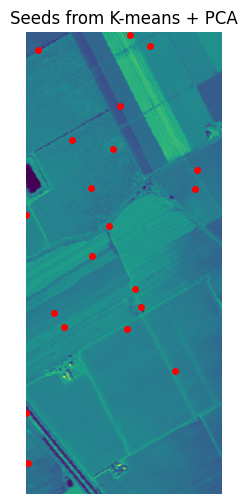

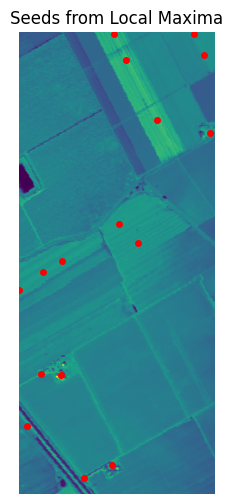

<ipython-input-20-9ad9e2876d6b>:32: RuntimeWarning: invalid value encountered in log2
  return -np.sum(norm * np.log2(norm + 1e-6))


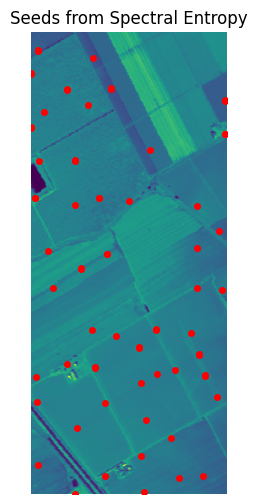

In [22]:
# PCA + KMeans
pca_data = pca_reduce(cleaned_data)
seeds_kmeans = kmeans_seeds(pca_data, n_clusters=20)
plot_seeds(X[:, :, 100], seeds_kmeans, "Seeds from K-means + PCA")

# Local maxima
seeds_local = local_maxima_seeds(cleaned_data, threshold = 0.7 , size = 30)
plot_seeds(X[:, :, 100], seeds_local, "Seeds from Local Maxima")

# Spectral entropy
seeds_entropy = entropy_seeds(cleaned_data, top_n = 20)
plot_seeds(X[:, :, 100], seeds_entropy, "Seeds from Spectral Entropy")

Seeded region growing algo

In [23]:
def region_growing(image, seeds, similarity_func, threshold, use_pca=True):
    if use_pca:
        image = pca_reduce(image)

    H, W, D = image.shape
    visited = np.zeros((H, W), dtype=bool)
    regions = np.full((H, W), -1, dtype=int)
    region_id = 0

    for seed in seeds:
        y, x = seed
        if visited[y, x]:
            continue

        queue = deque([(y, x)])
        visited[y, x] = True
        regions[y, x] = region_id
        seed_vec = image[y, x, :]

        while queue:
            cy, cx = queue.popleft()
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < H and 0 <= nx < W and not visited[ny, nx]:
                        neighbor_vec = image[ny, nx, :]
                        sim = similarity_func(seed_vec, neighbor_vec)
                        if sim < threshold:
                            visited[ny, nx] = True
                            regions[ny, nx] = region_id
                            queue.append((ny, nx))
        region_id += 1
    return regions


Different similarity functions can be used to measure similarity between pixels. Among these, Euclidean distance, Spectral Angle, and Cosine distance were tested.

In [24]:
def euclidean_distance(v1, v2):
    return np.linalg.norm(v1 - v2)

def spectral_angle(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return np.arccos(np.clip(cos_theta, -1, 1))

# cosine distance lower is better and is similar to spectral angle therefore is not tried below
def cosine_distance(v1, v2):
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return 1 - cos_sim

In [25]:
# def plot_regions(region_map, title="Region Segmentation"):
#     plt.figure(figsize=(8, 6))
#     cmap = plt.cm.get_cmap('tab20', np.max(region_map) + 1)
#     norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, np.max(region_map)+1.5), ncolors=256)

#     plt.imshow(region_map, cmap=cmap, norm=norm)
#     plt.colorbar(ticks=np.arange(0, np.max(region_map)+1))
#     plt.title(title)
#     plt.axis('off')
#     plt.show()

In [26]:
def plot_regions(region_map, title="Region Segmentation"):
    plt.figure(figsize=(8, 6))

    n_labels = np.max(region_map) + 1
    colors = plt.cm.hsv(np.linspace(0, 1, n_labels))
    cmap = mcolors.ListedColormap(colors)

    norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, n_labels + 0.5), ncolors=n_labels)

    plt.imshow(region_map, cmap=cmap, norm=norm)
    plt.colorbar(ticks=np.arange(n_labels))
    plt.title(title)
    plt.axis('off')
    plt.show()


The cleaned data, normalized using Z-score normalization, is used. Different seed selection criteria were tested. While the number of seeds can be specified directly in K-Means, this approach is not logically appropriate for methods like Local Maxima or Entropy-based seed selection. In such cases, the number of seeds can be adjusted indirectly by changing the threshold. The Seeded Region Growing algorithm was applied using various seed selection criteria.

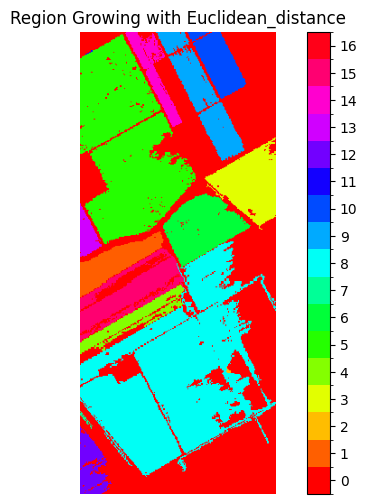

In [27]:
#euclidean distance and using kmeans
regions = region_growing(zscore_data, seeds_kmeans, euclidean_distance, threshold=6.5, use_pca=True)
plot_regions(regions, title="Region Growing with Euclidean_distance")

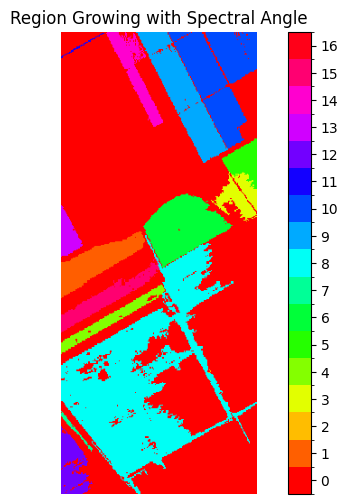

In [28]:
#spectral angle and using kmeans
regions = region_growing(zscore_data, seeds_kmeans, spectral_angle, threshold=0.4, use_pca=True)
plot_regions(regions, title="Region Growing with Spectral Angle")

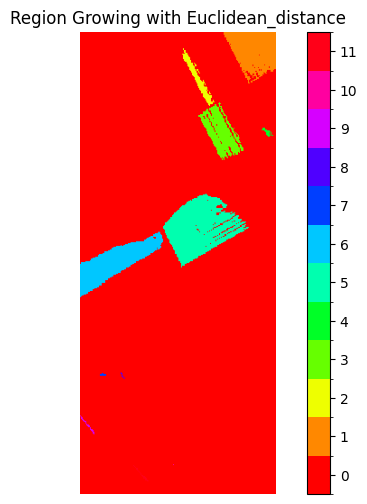

In [29]:
#euclidean distance and using local maxima
regions = region_growing(zscore_data, seeds_local, euclidean_distance, threshold=6.5, use_pca=True)
plot_regions(regions, title="Region Growing with Euclidean_distance")

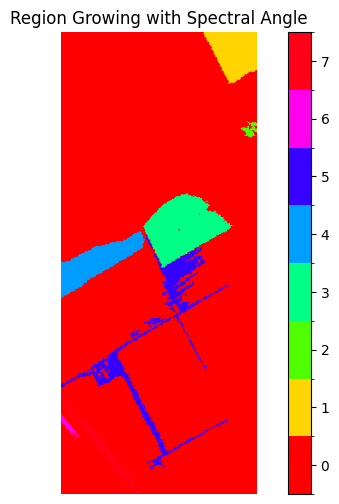

In [30]:
#spectral angle and using local maxima
regions = region_growing(zscore_data, seeds_local, spectral_angle, threshold=0.4, use_pca=True)
plot_regions(regions, title="Region Growing with Spectral Angle")

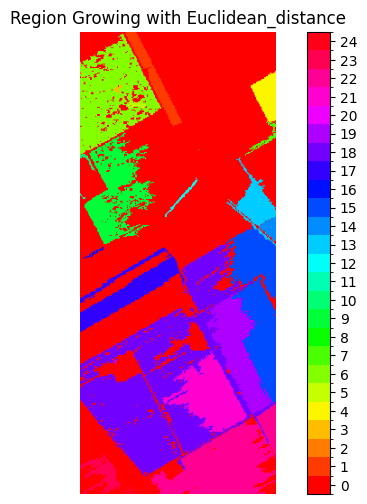

In [31]:
#euclidean distance and using spectral entropy
regions = region_growing(zscore_data, seeds_entropy, euclidean_distance, threshold=6.5, use_pca=True)
plot_regions(regions, title="Region Growing with Euclidean_distance")

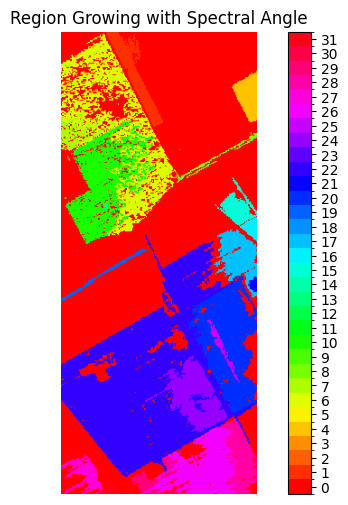

In [32]:
#spectral angle and using spectral entropy
regions = region_growing(zscore_data, seeds_entropy, spectral_angle, threshold=0.4, use_pca=True)
plot_regions(regions, title="Region Growing with Spectral Angle")

As observed, the threshold must be set appropriately for accurate segmentation. A higher threshold may result in over-segmentation, while a lower threshold can lead to under-segmentation. In the current implementation, the threshold is not tuned. From the segmented region plots, it can be seen that K-Means uses an intermediate number of seeds compared to the Local Maxima and Spectral Entropy methods. Local Maxima, with a higher seed count, resulted in over-segmented regions, while Spectral Entropy, with a lower seed count, produced under-segmented regions.

The cleaned data with snr, normalized using Z-score normalization, is used.

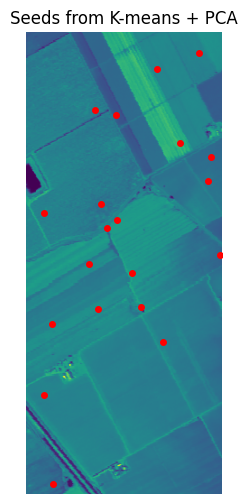

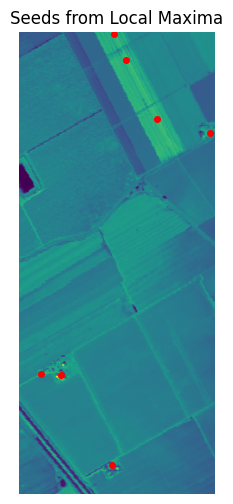

<ipython-input-20-9ad9e2876d6b>:32: RuntimeWarning: invalid value encountered in log2
  return -np.sum(norm * np.log2(norm + 1e-6))


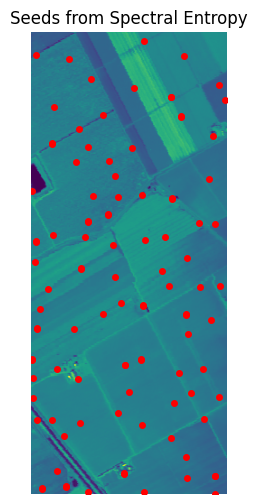

In [33]:
# PCA + KMeans
pca_data_snr = pca_reduce(cleaned_data_snr)
seeds_kmeans_snr = kmeans_seeds(pca_data_snr, n_clusters=20)
plot_seeds(X[:, :, 100], seeds_kmeans_snr, "Seeds from K-means + PCA")

# Local maxima
seeds_local_snr = local_maxima_seeds(cleaned_data_snr, threshold = 0.7 , size = 30)
plot_seeds(X[:, :, 100], seeds_local_snr, "Seeds from Local Maxima")

# Spectral entropy
seeds_entropy_snr = entropy_seeds(cleaned_data_snr, top_n = 20)
plot_seeds(X[:, :, 100], seeds_entropy_snr, "Seeds from Spectral Entropy")

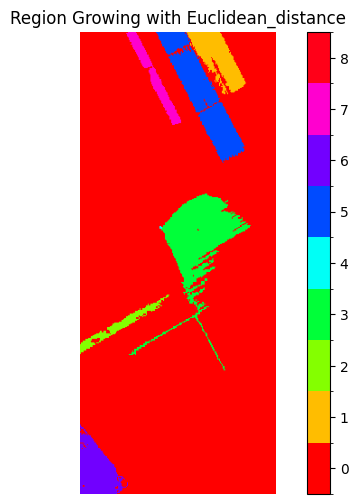

In [34]:
#euclidean distance and using kmeans
regions = region_growing(zscore_data_snr, seeds_kmeans_snr, euclidean_distance, threshold=6.5, use_pca=True)
plot_regions(regions, title="Region Growing with Euclidean_distance")

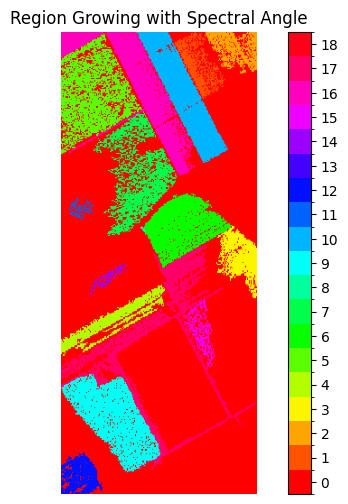

In [35]:
#spectral angle and using kmeans
regions = region_growing(zscore_data_snr, seeds_kmeans_snr, spectral_angle, threshold=0.4, use_pca=True)
plot_regions(regions, title="Region Growing with Spectral Angle")

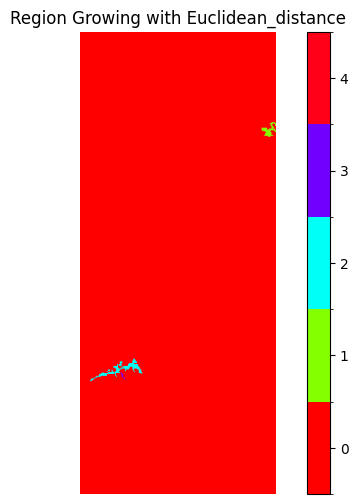

In [36]:
#euclidean distance and using local maxima
regions = region_growing(zscore_data_snr, seeds_local_snr, euclidean_distance, threshold=6.5, use_pca=True)
plot_regions(regions, title="Region Growing with Euclidean_distance")

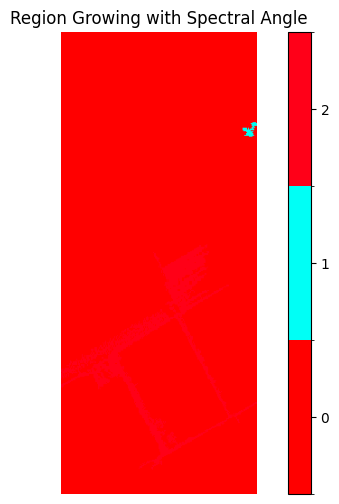

In [37]:
#spectral angle and using local maxima
regions = region_growing(zscore_data_snr, seeds_local_snr, spectral_angle, threshold=0.4, use_pca=True)
plot_regions(regions, title="Region Growing with Spectral Angle")

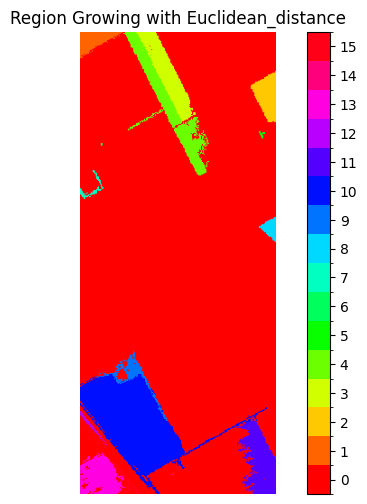

In [38]:
#euclidean distance and using spectral entropy
regions = region_growing(zscore_data_snr, seeds_entropy_snr, euclidean_distance, threshold=6.5, use_pca=True)
plot_regions(regions, title="Region Growing with Euclidean_distance")

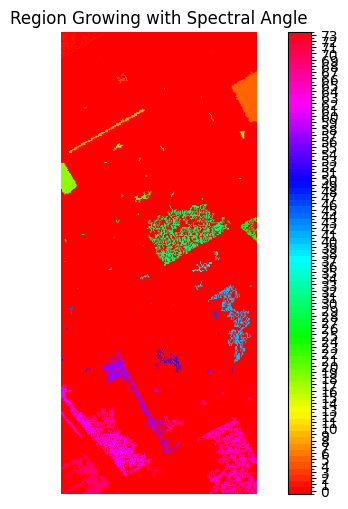

In [39]:
#spectral angle and using spectral entropy
regions = region_growing(zscore_data_snr, seeds_entropy_snr, spectral_angle, threshold=0.4, use_pca=True)
plot_regions(regions, title="Region Growing with Spectral Angle")

In the above implementation, PCA is used for faster image segmentation. However, using all the filtered bands instead of PCA can lead to higher accuracy, at the cost of increased computational time and resources. This approach is demonstrated below, using the same method as above but with all filtered bands and PCA set to False

For the cleaned data obtained by removing noisy bands.

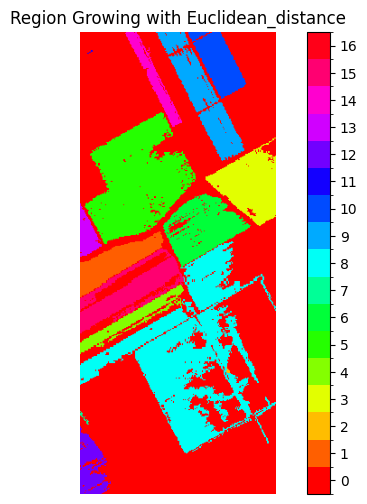

In [40]:
#euclidean distance and using kmeans
regions = region_growing(zscore_data, seeds_kmeans, euclidean_distance, threshold=6.5, use_pca=False)
plot_regions(regions, title="Region Growing with Euclidean_distance")

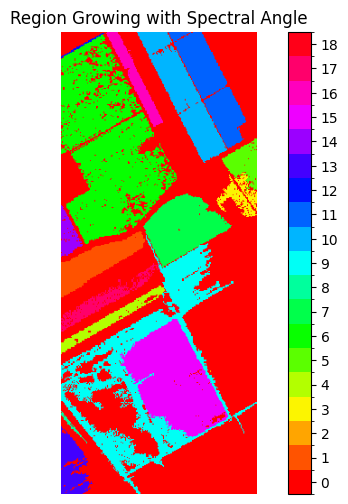

In [41]:
#spectral angle and using kmeans
regions = region_growing(zscore_data, seeds_kmeans, spectral_angle, threshold=0.4, use_pca=False)
plot_regions(regions, title="Region Growing with Spectral Angle")

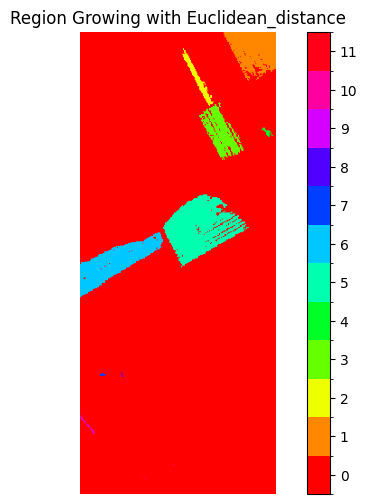

In [42]:
#euclidean distance and using local maxima
regions = region_growing(zscore_data, seeds_local, euclidean_distance, threshold=6.5, use_pca=False)
plot_regions(regions, title="Region Growing with Euclidean_distance")

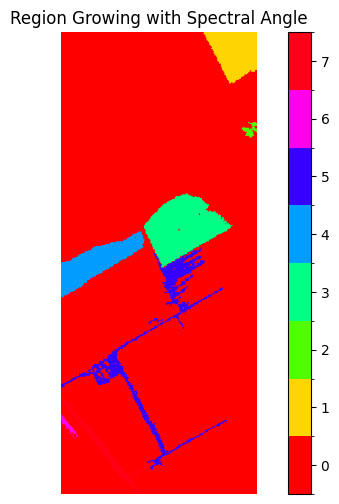

In [43]:
#spectral angle and using local maxima
regions = region_growing(zscore_data, seeds_local, spectral_angle, threshold=0.4, use_pca=False)
plot_regions(regions, title="Region Growing with Spectral Angle")

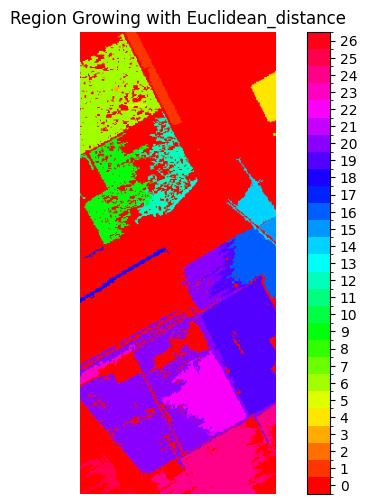

In [44]:
#euclidean distance and using spectral entropy
regions = region_growing(zscore_data, seeds_entropy, euclidean_distance, threshold=6.5, use_pca=False)
plot_regions(regions, title="Region Growing with Euclidean_distance")

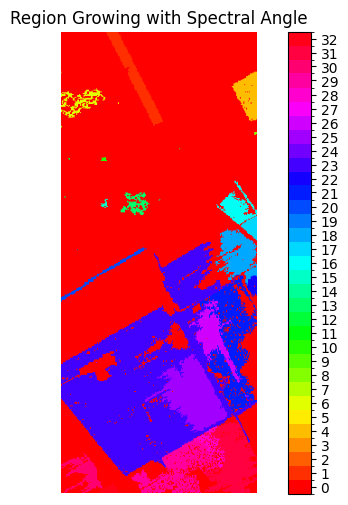

In [45]:
#spectral angle and using spectral entropy
regions = region_growing(zscore_data, seeds_entropy, spectral_angle, threshold=0.4, use_pca=False)
plot_regions(regions, title="Region Growing with Spectral Angle")

For the cleaned data obtained by removing noisy bands using snr.

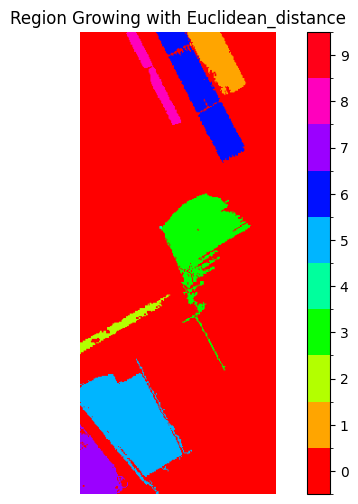

In [46]:
#euclidean distance and using kmeans
regions = region_growing(zscore_data_snr, seeds_kmeans_snr, euclidean_distance, threshold=6.5, use_pca=False)
plot_regions(regions, title="Region Growing with Euclidean_distance")

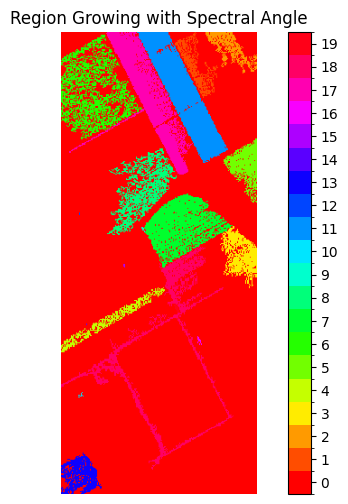

In [47]:
#spectral angle and using kmeans
regions = region_growing(zscore_data_snr, seeds_kmeans_snr, spectral_angle, threshold=0.4, use_pca=False)
plot_regions(regions, title="Region Growing with Spectral Angle")

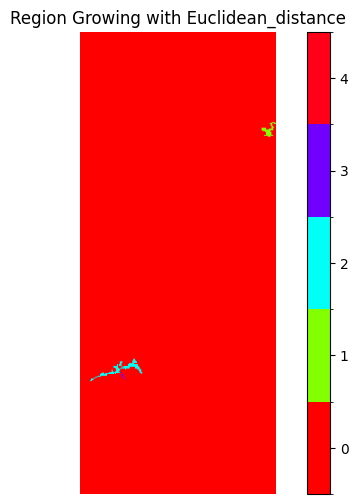

In [48]:
#euclidean distance and using local maxima
regions = region_growing(zscore_data_snr, seeds_local_snr, euclidean_distance, threshold=6.5, use_pca=False)
plot_regions(regions, title="Region Growing with Euclidean_distance")

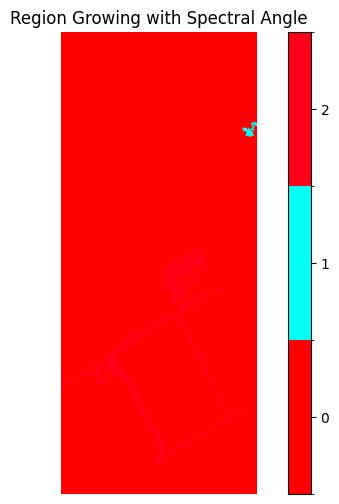

In [49]:
#spectral angle and using local maxima
regions = region_growing(zscore_data_snr, seeds_local_snr, spectral_angle, threshold=0.4, use_pca=False)
plot_regions(regions, title="Region Growing with Spectral Angle")

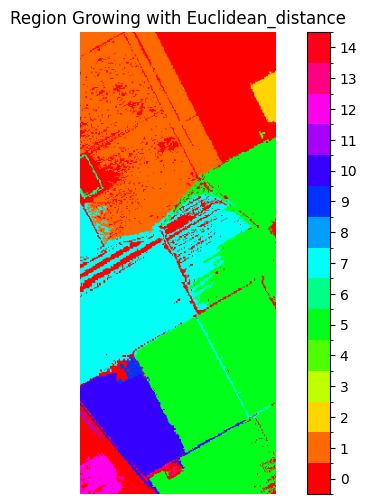

In [50]:
#euclidean distance and using spectral entropy
regions = region_growing(zscore_data_snr, seeds_entropy_snr, euclidean_distance, threshold=6.5, use_pca=False)
plot_regions(regions, title="Region Growing with Euclidean_distance")

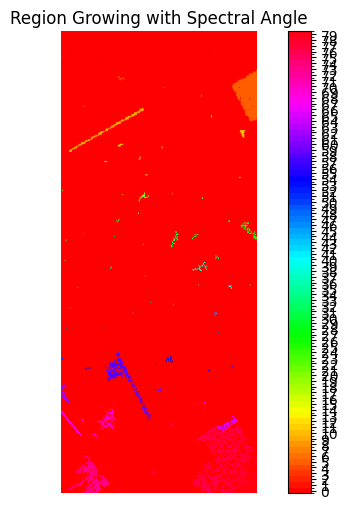

In [51]:
#spectral angle and using spectral entropy
regions = region_growing(zscore_data_snr, seeds_entropy_snr, spectral_angle, threshold=0.4, use_pca=False)
plot_regions(regions, title="Region Growing with Spectral Angle")

with out tuning the threshold and the number of seeds the best results are obtained form kmeans seed selectig so moving forward

Limiting the number of pixels in a region during Seeded Region Growing is called a **region size constraint**. It restricts how large each segmented region can grow, regardless of similarity. This is useful to prevent regions from expanding too much in noisy or ambiguous areas, ensures balanced region sizes when multiple seeds are used, and adds control in applications where object sizes are known or expected (e.g., tumors in medical images). It helps maintain meaningful and consistent segmentation results.
Below is the implementation for this, included in seeded region growing algo.

In [52]:
def region_growing_constrained(image, seeds, similarity_func, threshold, use_pca=True, max_region_size=None):
    if use_pca:
        image = pca_reduce(image)

    H, W, D = image.shape
    visited = np.zeros((H, W), dtype=bool)
    regions = np.full((H, W), -1, dtype=int)
    region_id = 0

    for seed in seeds:
        y, x = seed
        if visited[y, x]:
            continue

        queue = deque([(y, x)])
        visited[y, x] = True
        regions[y, x] = region_id
        seed_vec = image[y, x, :]
        region_size = 1  # Initialize region size

        while queue:
            if max_region_size is not None and region_size >= max_region_size:
                break

            cy, cx = queue.popleft()
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < H and 0 <= nx < W and not visited[ny, nx]:
                        neighbor_vec = image[ny, nx, :]
                        sim = similarity_func(seed_vec, neighbor_vec)
                        if sim < threshold:
                            visited[ny, nx] = True
                            regions[ny, nx] = region_id
                            queue.append((ny, nx))
                            region_size += 1
                            if max_region_size is not None and region_size >= max_region_size:
                                break
                if max_region_size is not None and region_size >= max_region_size:
                    break

        region_id += 1

    return regions


The above method was applied to the previously used hyperspectral image, utilizing **spectral angle** as the similarity measure. The data was preprocessed using **z-score normalization** and evaluated using both the **z-scored data** and **SNR (Signal-to-Noise Ratio) data** and using k-means seed.


In the code below, the similarity threshold is increased from **0.4 to 0.6**, and a **maximum region size constraint of 11,000 pixels** is applied. Given the image dimensions, this constraint is expected to produce approximately **10 regions**.


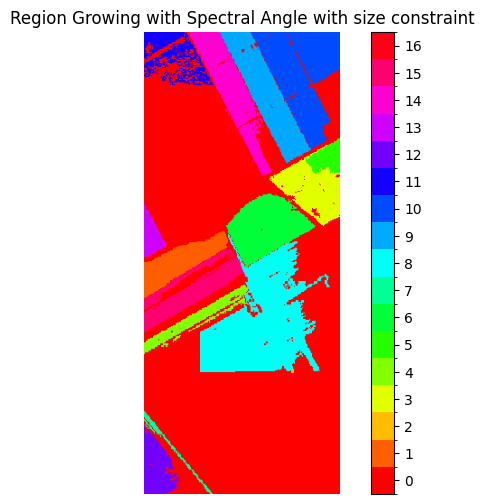

In [53]:
#spectral angle and using kmeans
regions = region_growing_constrained(zscore_data, seeds_kmeans, spectral_angle, threshold=0.6, use_pca=True,max_region_size = 11000)
plot_regions(regions, title="Region Growing with Spectral Angle with size constraint")

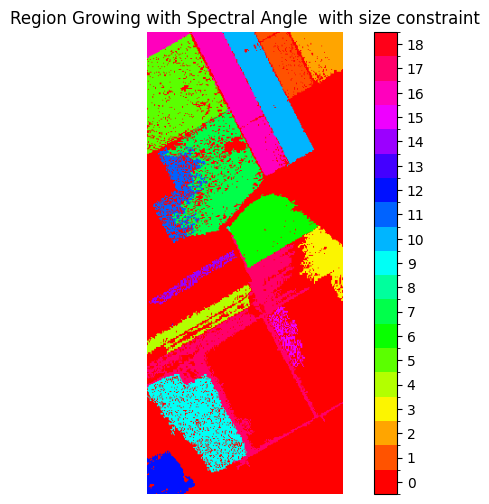

In [54]:
#spectral angle and using kmeans
regions = region_growing_constrained(zscore_data_snr, seeds_kmeans_snr, spectral_angle, threshold=0.6, use_pca=False, max_region_size = 11000)
plot_regions(regions, title="Region Growing with Spectral Angle  with size constraint")

The above results show a clear improvement compared to the region growing algorithm **without** the maximum region size constraint. In the unconstrained case, increasing the similarity threshold often causes neighboring regions to **merge incorrectly**, resulting in a single region where there should have been **two distinct regions**. By enforcing a region size limit, the algorithm maintains better control over region boundaries and preserves meaningful segmentation, even at higher thresholds.


Some other commonly used images for segmentation tasks include Indian Pines and Salinas-A Scene.